# Molecular DFT Visualization

*Seeing* the full 3D solver's output, the same way
`HF_solver/Hartree_Fock.ipynb` and `Diatomic_HF_solver/Diatomic_Visualization.ipynb`
did for the atomic and diatomic solvers -- builds on the validated SCF
from `Molecular_DFT_Plan.md` Phases 1-5, no new physics here.

Unlike the diatomic solver (reduced to a 2D `(mu,nu)` grid by exploiting
axial symmetry), this solver never assumes any symmetry at all -- so
instead of a single 2D cross-section, the natural way to see the density
is a genuine 3D isosurface.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from skimage.measure import marching_cubes

import grid3d
import scf3d

## H2 electron density: 3D isosurfaces

Two isovalues tell two different parts of the story: a high one (`80%`
of the peak density) isolates the densest core region, and a low one
(`3%`) shows the full extended cloud.

H2: E_total=-1.24851 Ha, 20 iterations, N_check=2.00000, rho max=0.2200


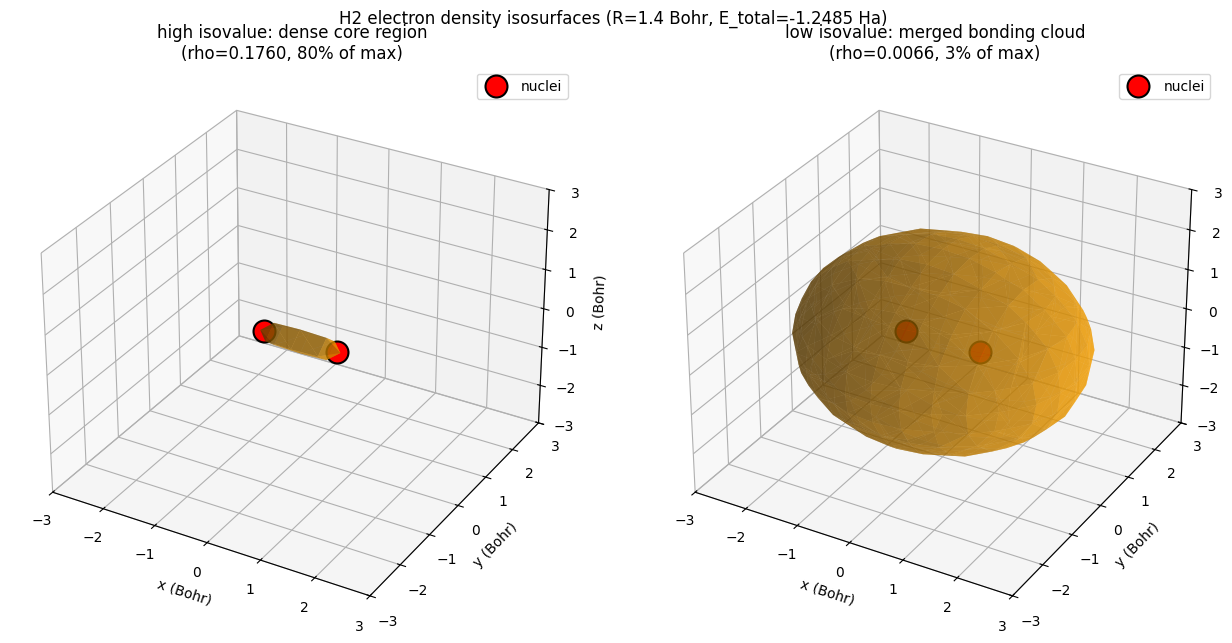

In [2]:
L, N = 16.0, 32
x, X, Y, Z, dx = grid3d.make_grid(L, N)
_, _, _, G2 = grid3d.g_vectors(L, N)
grid = (x, X, Y, Z, dx, G2)

R = 1.4  # known H2 equilibrium bond length, Bohr
softening = dx * 0.5
nuclei = [(1.0, -R / 2, 0.0, 0.0, softening), (1.0, R / 2, 0.0, 0.0, softening)]
result = scf3d.run_scf(nuclei, 2, grid, method='lda', n_states=3, max_iter=50)
rho = result['rho']
print(f"H2: E_total={result['E_total']:.5f} Ha, {result['iterations']} iterations, "
      f"N_check={result['N_check']:.5f}, rho max={rho.max():.4f}")

fig = plt.figure(figsize=(13, 6.5))
lim = 3
for i, (frac, ax_title) in enumerate([(0.8, 'high isovalue: dense core region'),
                                        (0.03, 'low isovalue: merged bonding cloud')]):
    iso_level = rho.max() * frac
    verts, faces, normals, values = marching_cubes(rho, level=iso_level, spacing=(dx, dx, dx))
    verts += np.array([x[0], x[0], x[0]])  # shift to match the (centered) grid coordinates

    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2], color='orange', alpha=0.6, shade=True)
    ax.scatter([-R / 2, R / 2], [0, 0], [0, 0], color='red', s=250, edgecolor='black',
               linewidth=1.5, depthshade=False, label='nuclei', zorder=10)
    ax.set_xlabel('x (Bohr)'); ax.set_ylabel('y (Bohr)'); ax.set_zlabel('z (Bohr)')
    ax.set_title(f'{ax_title}\n(rho={iso_level:.4f}, {frac*100:.0f}% of max)')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.legend()

fig.suptitle(f'H2 electron density isosurfaces (R={R} Bohr, E_total={result["E_total"]:.4f} Ha)')
fig.tight_layout()
fig.savefig('media/h2_density_isosurfaces.png', dpi=120)
plt.show()

The high-isovalue surface is a single connected cylinder bridging the
two nuclei, not two separate atomic lobes -- the classic real-space
signature of a covalent bond, falling straight out of the SCF with
absolutely no bonding assumption built into the solver (no basis
functions centered on atoms, no symmetry reduction -- just a plain
uniform grid and FFT operators). The low-isovalue surface shows the full
extended density cloud enclosing both nuclei, consistent with the
diatomic solver's `Diatomic_Visualization.ipynb` cross-section (which
found the same bonding-charge bridge by a completely different method).

## H2 electron density: 2D cross-section through the bond axis

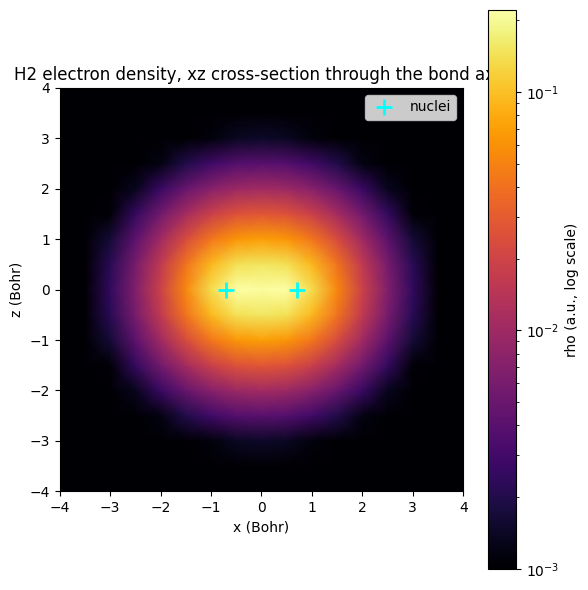

In [3]:
mid = N // 2
rho_slice = rho[:, mid, :]  # xz-plane through y=0, containing both nuclei

fig, ax = plt.subplots(figsize=(6, 6))
norm = LogNorm(vmin=1e-3, vmax=rho.max())
pcm = ax.pcolormesh(x, x, np.clip(rho_slice, 1e-3, None).T, shading='gouraud', cmap='inferno', norm=norm)
ax.plot([-R / 2, R / 2], [0, 0], color='cyan', marker='+', linestyle='none',
        markersize=12, markeredgewidth=2, label='nuclei')
ax.set_aspect('equal')
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_xlabel('x (Bohr)'); ax.set_ylabel('z (Bohr)')
ax.set_title('H2 electron density, xz cross-section through the bond axis')
fig.colorbar(pcm, ax=ax, label='rho (a.u., log scale)')
ax.legend()
fig.tight_layout()
fig.savefig('media/h2_density_slice.png', dpi=120)
plt.show()

## Hydrogen: convergence to the exact answer with grid resolution

From `Atom_SCF_Validation.ipynb` (Phase 3) -- energies already validated
there, plotted here rather than re-run (the `N=64` case alone takes
about 16 minutes on this session's hardware).

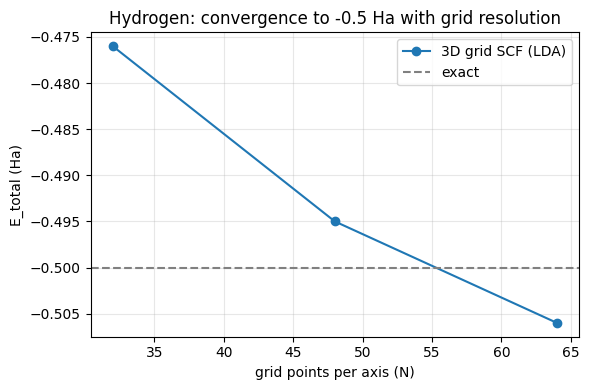

In [4]:
N_values = [32, 48, 64]
E_values = [-0.476, -0.495, -0.506]  # softening=0.5*dx held fixed at each resolution

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(N_values, E_values, 'o-', label='3D grid SCF (LDA)')
ax.axhline(-0.5, color='gray', ls='--', label='exact')
ax.set_xlabel('grid points per axis (N)'); ax.set_ylabel('E_total (Ha)')
ax.set_title('Hydrogen: convergence to -0.5 Ha with grid resolution')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/hydrogen_resolution_convergence.png', dpi=110)
plt.show()

Genuine convergence toward the exact answer, at real computational cost
(`N=64` took roughly 30x longer than `N=32`) -- exactly the tradeoff this
whole project's Scope decision anticipated: general 3D machinery that
works, at a resolution deliberately kept modest for this initial build.